# 🤖 Notebook 04 — Model Training & Evaluation

**Input:** `data/processed/features.csv`  
**Output:** `models/best_model.pkl` + `models/random_forest.pkl`  

---

## Models Compared

| Model | Strength | Weakness |
|---|---|---|
| Decision Tree | Fast, interpretable | Overfits |
| **Random Forest** | Best baseline for IMU | Slower |
| SVM | Good with scaled features | Slow on large data |
| KNN | Simple | Slow at inference |
| XGBoost | Top accuracy | Needs tuning |

**Expected winner: Random Forest or XGBoost.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.feature_engineering import apply_sliding_window, split_dataset
from src.train_model import (
    get_models, evaluate_model, plot_comparison,
    plot_confusion_matrix, plot_feature_importance, save_best_model
)

print('All imports OK')

All imports OK


In [2]:
# ── Load features (or regenerate) ────────────────────────────────
feat_path = '../data/processed/features.csv'
raw_path  = '../data/synthetic/helmet_imu_raw.csv'

if os.path.exists(feat_path):
    feature_df = pd.read_csv(feat_path)
    print(f'Loaded features: {feature_df.shape}')
else:
    print('Feature file not found. Regenerating...')
    df = pd.read_csv(raw_path)
    feature_df = apply_sliding_window(df, verbose=True)
    os.makedirs('../data/processed', exist_ok=True)
    feature_df.to_csv(feat_path, index=False)

display(feature_df.head(3))

Loaded features: (4500, 72)


,ax_mean,ax_std,ax_max,ax_min,ax_range,ax_var,ax_rms,ax_iqr,ax_skew,ay_mean,...,jerk_mean,jerk_max,jerk_std,tilt_mean_deg,tilt_max_deg,tilt_std_deg,corr_ax_ay,corr_ax_az,label,session_id
0,-0.00476,0.256842,0.3668,-0.5853,0.9521,0.065968,0.256886,0.458050,-0.426511,0.062295,...,0.505718,0.879622,0.185986,1.787590,4.440949,0.952965,-0.262813,-0.027013,0,0
1,0.05451,0.217228,0.5304,-0.2877,0.8181,0.047188,0.223963,0.296975,0.375577,0.021875,...,0.434104,0.667902,0.166501,1.463308,3.199747,0.809159,-0.318054,0.121399,0,0
2,0.02232,0.266941,0.6385,-0.3555,0.9940,0.071258,0.267873,0.349400,0.683478,0.000575,...,0.537574,0.962353,0.223786,1.803646,3.763721,0.973227,-0.113761,-0.261017,0,0


In [3]:
# ── Train / Test split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = split_dataset(feature_df, test_size=0.2, seed=42)
feature_cols = X_train.columns.tolist()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Features: {len(feature_cols)}')

X_train: (3600, 70), X_test: (900, 70)
Features: 70


In [4]:
# ── Train all models ──────────────────────────────────────────────
# This cell will take a few minutes depending on your machine
models  = get_models()
results = []

for name, model in models.items():
    print(f'\nTraining: {name}...')
    res = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    results.append(res)

print('\n✅ All models trained!')


Training: Decision Tree...

  Decision Tree
  Accuracy          : 0.9411
  F1 (macro)        : 0.8572
  F1 (weighted)     : 0.9421

              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97       741
     Pothole       0.71      0.82      0.76        49
 SuddenBrake       0.83      0.90      0.86        49
       Crash       0.84      0.84      0.84        61

    accuracy                           0.94       900
   macro avg       0.84      0.88      0.86       900
weighted avg       0.94      0.94      0.94       900


Training: Random Forest...

  Random Forest
  Accuracy          : 0.9489
  F1 (macro)        : 0.8781
  F1 (weighted)     : 0.9509

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97       741
     Pothole       0.75      0.88      0.81        49
 SuddenBrake       0.75      0.94      0.84        49
       Crash       0.84      0.95      0.89        61

    accuracy               

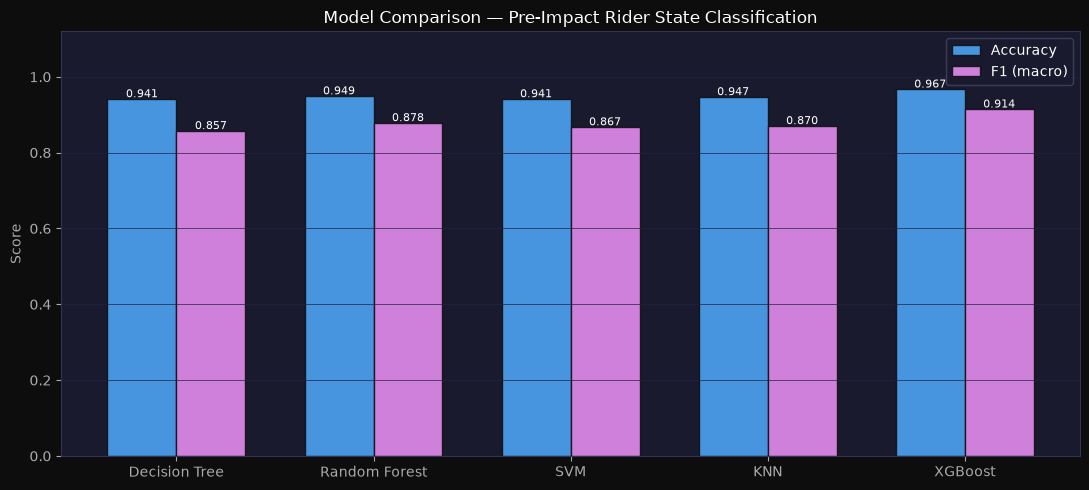

In [5]:
# ── Model comparison bar chart ────────────────────────────────────
plot_comparison(results)

Best model: XGBoost (F1 macro = 0.9141)


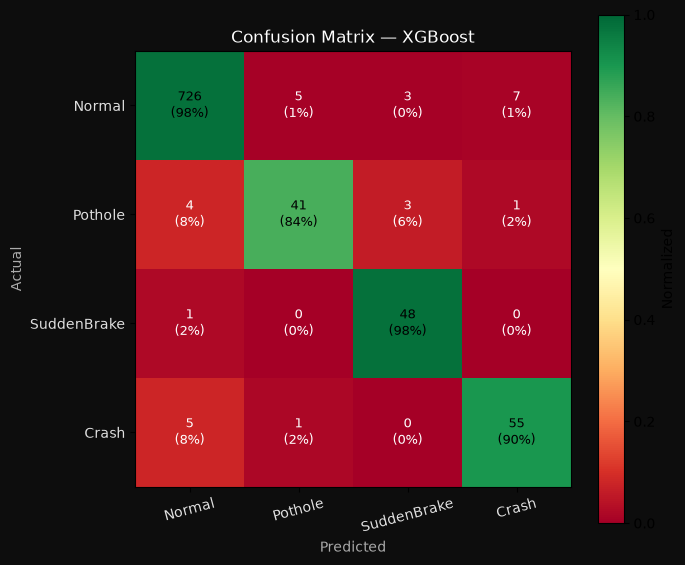

In [6]:
# ── Confusion matrix — best model ────────────────────────────────
best_result = max(results, key=lambda r: r['f1_macro'])
print(f'Best model: {best_result["model_name"]} (F1 macro = {best_result["f1_macro"]:.4f})')
plot_confusion_matrix(best_result)

Random Forest confusion matrix:


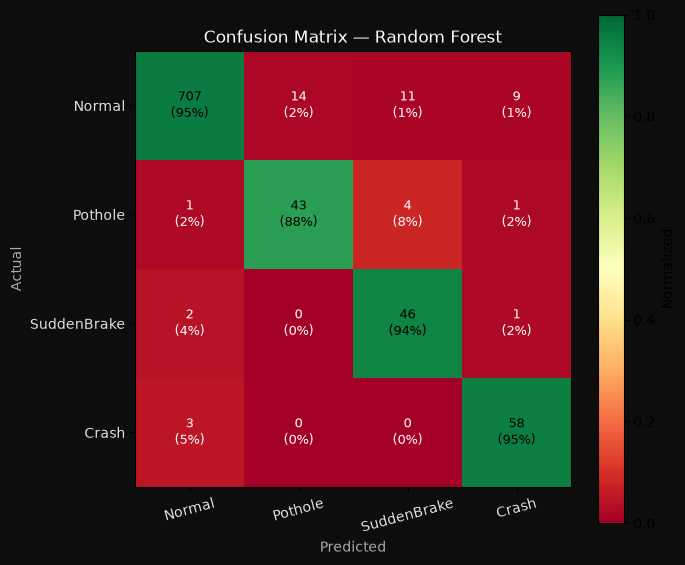

In [7]:
# ── Confusion matrix — Random Forest (always show for comparison) ─
rf_result = next((r for r in results if 'Random Forest' in r['model_name']), None)
if rf_result:
    print('Random Forest confusion matrix:')
    plot_confusion_matrix(rf_result)

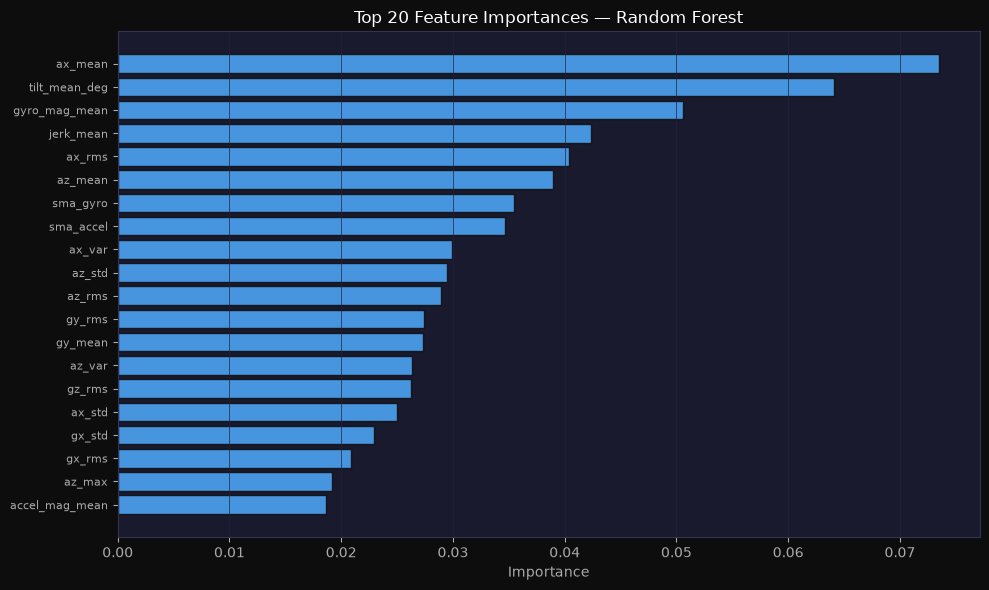

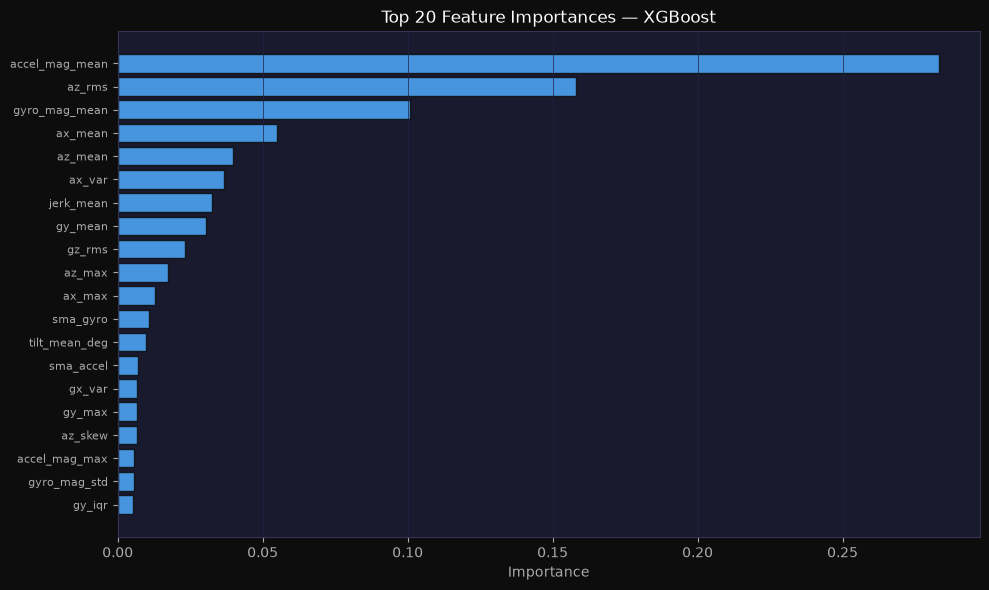

In [8]:
# ── Feature importance ────────────────────────────────────────────
if rf_result:
    plot_feature_importance(rf_result['model'], feature_cols, top_n=20, title='Random Forest')

plot_feature_importance(best_result['model'], feature_cols, top_n=20, title=best_result['model_name'])

In [9]:
# ── Save models ───────────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)
best = save_best_model(results, feature_cols, save_dir='../models')


✅ Best model : XGBoost
   Accuracy   : 0.9667
   F1 (macro) : 0.9141
   Saved to   : ../models\best_model.pkl
   Meta saved : ../models\model_meta.pkl
   RF saved   : ../models\random_forest.pkl


In [10]:
# ── Summary table ─────────────────────────────────────────────────
summary = pd.DataFrame([{
    'Model'      : r['model_name'],
    'Accuracy'   : f"{r['accuracy']:.4f}",
    'F1 Macro'   : f"{r['f1_macro']:.4f}",
    'F1 Weighted': f"{r['f1_weighted']:.4f}"
} for r in results]).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print('\n=== FINAL MODEL COMPARISON ===')
display(summary)
print(f'\n✅ Best: {best["model_name"]} saved to models/')
print('\nNext: Run src/predict.py to simulate live prediction!')


=== FINAL MODEL COMPARISON ===


,Model,Accuracy,F1 Macro,F1 Weighted
0,XGBoost,0.9667,0.9141,0.9668
1,Random Forest,0.9489,0.8781,0.9509
2,KNN,0.9467,0.8703,0.9472
3,SVM,0.9411,0.8671,0.9438
4,Decision Tree,0.9411,0.8572,0.9421



✅ Best: XGBoost saved to models/

Next: Run src/predict.py to simulate live prediction!
